# Supply Chain Model example

In [1]:
from supply_chain_utils import *
from matplotlib import pyplot as plt

In [ ]:
# Generate a random cost curve for 300 plants at the downstream stage
capacities, costs = generate_cost_curve(n_plants=300)
# Generate exmaple intensities (linking two supply stages) and reference price
intensity = 5.6
p_u_ref = 0.1*(costs/intensity).min()
# Make the supply and demand curves and add them to a supply chain stage
supply_curve = SupplyCurve2D(capacities, costs, intensity=intensity, p_u_ref=p_u_ref, eta=0.3)
demand = DemandCurve(A=10*capacities.sum(), elas=-0.3)
downstream = SupplyChainStage(supply_curve, demand)

# Generate a random cost curve for 150 plants at the upstream stage, the rest is similar to above
capacities, costs = generate_cost_curve(n_plants=150, max_cost_bounds=(100, 500), total_capacity_bounds=(2000, 3000))
supply_curve = SupplyCurve(capacities, costs, eta=0.1)
demand = CompositeDemand([downstream], other=520)
upstream = SupplyChainStage(supply_curve, demand)

In [7]:
# Calculate the equilibrium price at the upstream stage
upstream.p_eq = upstream.get_equilibrium_price()
print(f"Upstream equilibrium price: {upstream.p_eq:.2f}")

Upstream equilibrium price: 68.42


In [8]:
# Calculate the equilibrium price at the downstream stage
downstream.p_eq = downstream.get_equilibrium_price(p_u=upstream.p_eq)
print(f"Upstream equilibrium price: {downstream.p_eq:.2f}")

Upstream equilibrium price: 1252.17


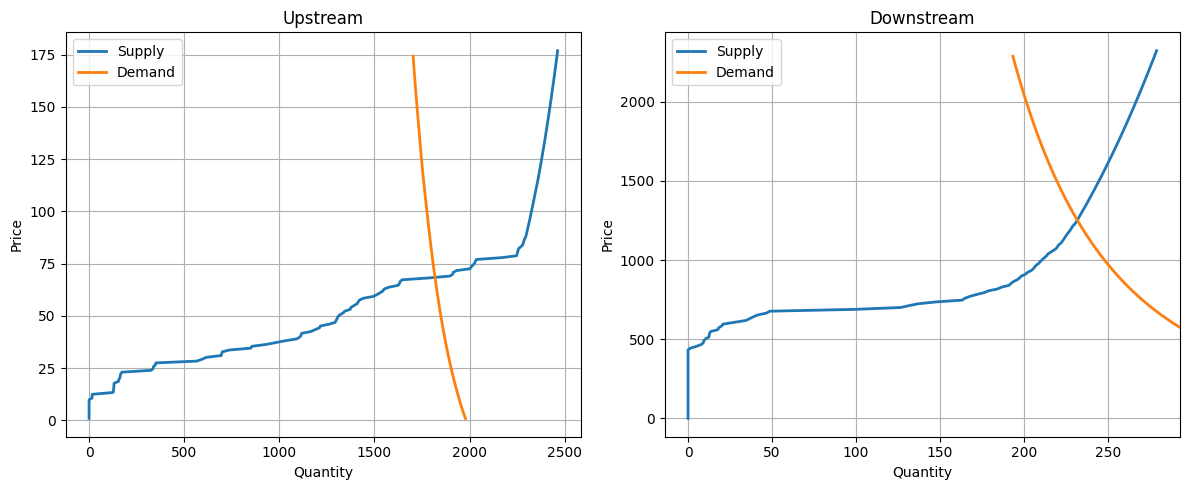

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

upstream.plot_sd(ax[0])
downstream.plot_sd(ax[1], p_u=upstream.p_eq)

ax[0].set_title('Upstream')
ax[1].set_title('Downstream')

ax[0].legend()
ax[1].legend()

fig.tight_layout()